# Modeling and evaluation

In the previous notebooks, we explored the dataset, handled missing values, engineered new features, transformed skewed variables, and encoded categorical data. The result is a fully numerical, modeling-ready dataset that captures many of the factors believed to influence house prices.

In this notebook, we focus on the machine learning stage of the project. We begin by establishing simple benchmark models to provide reference points for performance evaluation. We then train and compare several regression algorithms of increasing complexity, assessing their ability to predict house prices on unseen data.

Finally, we select the best-performing model, train it on the full training dataset, and generate predictions for the Kaggle test set. These predictions are used to create a submission file that can be uploaded to the competition leaderboard.

The objective is not only to obtain accurate predictions, but also to understand how different modeling approaches perform on this dataset and how the feature engineering decisions made in the previous notebooks contribute to the final results.

## Import libraries

First, import the libraries used throughout the analysis.

In [45]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Modeling
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


## Load the processed dataset

In the previous notebook, we saved the fully processed dataset after completing feature engineering, skewness corrections, and categorical encoding. By loading the processed data directly, we avoid repeating the preprocessing pipeline and can focus exclusively on model development and evaluation.

We load both the transformed dataset and the accompanying feature metadata table. The metadata will be useful for understanding the origin and characteristics of the features used throughout the modeling process.

In [46]:
# Load data processed and saved in the feature engineering notebook
df_full = pd.read_parquet(
    "processed_data/02_data.parquet"
)
df_features = pd.read_parquet(
    "processed_data/02_features.parquet"
)

In [47]:
df_full

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,21.0,1936,4,7,1970,1970,0.0,0.0,...,0,0,0,1,0,0,0,0,1,0
2915,2916,160,21.0,1894,4,5,1970,1970,0.0,252.0,...,0,0,0,1,1,0,0,0,0,0
2916,2917,20,160.0,20000,5,7,1960,1996,0.0,1224.0,...,0,0,0,1,1,0,0,0,0,0
2917,2918,85,62.0,10441,5,5,1992,1992,0.0,337.0,...,0,0,0,1,0,0,0,0,1,0


In [48]:
df_features

,Name,Type,Category,Source,Description,Skewness,LogTransform
0,MSSubClass,numerical,original,MSSubClass,Identifies the type of dwelling involved in th...,1.375457,True
1,MSZoning,categorical,original,MSZoning,Identifies the general zoning classification o...,NaN,False
2,LotFrontage,numerical,original,LotFrontage,Linear feet of street connected to property,0.022013,False
3,LotArea,numerical,original,LotArea,Lot size in square feet,12.822431,True
4,Street,categorical,original,Street,Type of road access to property,NaN,False
...,...,...,...,...,...,...,...
91,IsRemodeled,numerical,indicator,YearBuilt;YearRemodAdd,Indicates whether the property has been remodeled,0.138046,False
92,HasPool,numerical,indicator,PoolArea,Indicates whether the property has a pool,14.884318,True
93,HasGarage,numerical,indicator,YearBuilt;YearRemodAdd,Indicates whether the property has a garage,-3.941054,False
94,HasBasement,numerical,indicator,TotalBsmtSF,Indicates whether the property has a basement,-5.828995,False


## Separate training and test data

Throughout the exploratory analysis and feature engineering stages, the training and test datasets were combined to ensure that preprocessing steps were applied consistently. Before training any models, however, we must restore the original split.

Using the `IsTrainSet` indicator, we separate the observations belonging to the Kaggle training set from those belonging to the Kaggle test set. The training data contains the target variable, `SalePrice`, and will be used to train and evaluate our models. The test data will be reserved for generating the final competition submission.

In [49]:
# Separate train and test sets
df_train = df_full.loc[df_full["IsTrainSet"]].copy()
df_test = df_full.loc[~df_full["IsTrainSet"]].copy()

# Separate features and target
X_train = df_train.drop(
    columns=["SalePrice", "IsTrainSet"]
)

y_train = df_train["SalePrice"]

X_test = df_test.drop(
    columns=["SalePrice", "IsTrainSet"]
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1460
Test samples: 1459
Number of features: 321


## Validation strategy

The ultimate goal of a machine learning model is not to perform well on the data used for training, but rather to generalize to new, unseen observations. Evaluating a model on the same data used to fit it can lead to overly optimistic performance estimates, since the model may partially memorize patterns specific to the training set.

To obtain a more realistic estimate of predictive performance, we reserve a portion of the data for validation. The model is trained using one subset of the data and evaluated on another subset that was not used during training. This provides a better indication of how the model is likely to perform when making predictions on new properties.

For this project, we use k-fold cross-validation. In this approach, the training data is divided into several folds. The model is trained multiple times, each time using a different fold for validation and the remaining folds for training. The final performance estimate is obtained by averaging the results across all folds.

Cross-validation makes more efficient use of the available data than a single train-validation split and generally provides a more stable estimate of model performance.

In [50]:
# Cross-validation method used for all models
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store the results for each model
results = []

## Baseline 1: Mean Predictor

Before evaluating machine learning models, it is useful to establish a simple baseline against which more sophisticated approaches can be compared.

The simplest possible predictor consists of assigning the same sale price to every property. A natural choice is the mean sale price observed in the training data. Although this model completely ignores the characteristics of each house, it provides a useful reference point: any predictive model should be able to outperform a strategy that predicts the average price for every observation.

By establishing this baseline, we can quantify the value added by increasingly complex models and determine whether the additional modeling effort leads to meaningful improvements in predictive performance.

In [51]:
mean_price = y_train.mean()

print(f"Mean SalePrice: ${mean_price:,.2f}")

Mean SalePrice: $180,921.20


In [52]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    y_train_fold = y_train.iloc[train_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    prediction = np.full(
        len(y_valid_fold),
        y_train_fold.mean()
    )

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Baseline 1 - Mean Predictor",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})


for k,v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Baseline 1 - Mean Predictor
RMSE Mean : 79244.56167175091
RMSE Std  : 5557.103420903318


## Baseline 2: Price-per-Area Model

A slightly more informative baseline can be constructed by incorporating one of the most influential predictors identified during the exploratory analysis: the total area of the property.

Instead of predicting a constant value for all observations, we assume that house prices scale linearly with size. Under this assumption, we estimate a single global price per square foot from the training data and use it to generate predictions.

### Method

We compute the average price per square foot using the training set:

In [53]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    # compute price per square foot using ONLY training fold
    avg_price_per_sf = y_train_fold.sum() / X_train_fold["TotalArea"].sum()

    # prediction on validation fold
    prediction = avg_price_per_sf * X_valid_fold["TotalArea"]

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)


results.append({
    "Model": "Baseline 2 - Price per Area",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})


for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Baseline 2 - Price per Area
RMSE Mean : 49131.168566007735
RMSE Std  : 7591.835544518436


### Motivation

Exploratory analysis indicated that property size is one of the strongest individual predictors of sale price. This baseline evaluates how much predictive signal can be extracted from size alone, without considering additional property characteristics such as quality, location, or amenities.

### Visualization

To better understand this relationship, we can visualize:

- A scatter plot of `TotalArea` vs. `SalePrice`
- The fitted linear relationship implied by the price-per-area model

This provides an intuitive view of how well a simple linear scaling captures the observed variation in house prices.

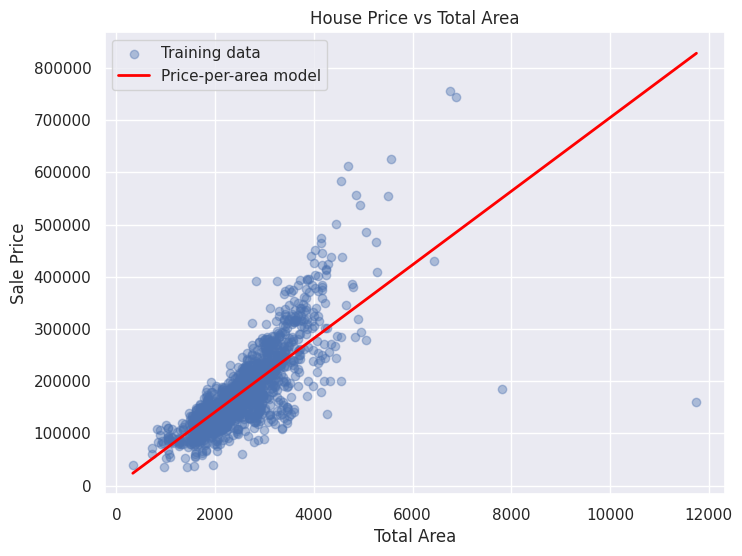

In [54]:
# Price-per-area coefficient (trained only on train set)
avg_price_per_sf = y_train.sum() / X_train["TotalArea"].sum()

# Scatter plot (training data only)
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train["TotalArea"],
    y_train,
    alpha=0.4,
    label="Training data"
)

# Line representing the model
x_vals = np.linspace(
    X_train["TotalArea"].min(),
    X_train["TotalArea"].max(),
    100
)

y_vals = avg_price_per_sf * x_vals

plt.plot(
    x_vals,
    y_vals,
    color="red",
    linewidth=2,
    label="Price-per-area model"
)

plt.title("House Price vs Total Area")
plt.xlabel("Total Area")
plt.ylabel("Sale Price")
plt.legend()
plt.show()

### Discussion

This model implicitly assumes that all houses have the same value per unit of area, regardless of differences in quality, neighborhood, condition, age, or additional features. As a result, it serves as a useful but limited benchmark, highlighting the need for more expressive models that can capture these additional sources of variation.

## Linear Regression

After establishing simple baselines, we now move to a standard machine learning model: linear regression. This model extends the price-per-area baseline by incorporating all available features and learning a weighted linear combination of them to predict house prices.

Unlike the previous baselines, which relied on strong simplifying assumptions, linear regression allows each feature to contribute independently to the prediction, making it a more flexible and expressive model while still maintaining interpretability.

### Motivation

Linear regression serves as a natural first machine learning model. It provides a strong, interpretable baseline that helps us understand how much predictive power can be extracted from the engineered feature set under a linear assumption.

### Evaluation

The model is evaluated using k-fold cross-validation to obtain a robust estimate of its generalization performance. The evaluation metric is Root Mean Squared Error (RMSE), which penalizes large prediction errors and is commonly used in regression problems such as this one.

- Train the model using the training set
- Evaluate performance using cross-validation RMSE
- Record results for comparison with other models

In [55]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)

    prediction = model.predict(X_valid_fold)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Linear Regression",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Linear Regression
RMSE Mean : 42114.85450634172
RMSE Std  : 16150.79821051806


## Random Forest Regressor

After establishing linear models and simple baselines, we now introduce a more flexible machine learning approach: the Random Forest Regressor. This model belongs to the family of ensemble methods and is capable of capturing complex nonlinear relationships and feature interactions without requiring manual specification.

Unlike linear regression, random forests do not assume a linear relationship between features and the target variable. Instead, they build multiple decision trees and aggregate their predictions, resulting in a model that is generally more robust to noise and better suited for structured tabular data such as the House Prices dataset.

### Motivation

Random forests can capture nonlinear dependencies and interactions between features automatically. This is particularly useful in this dataset, where variables such as quality, location, size, and amenities may interact in non-additive ways.

### Evaluation

The model is evaluated using the same k-fold cross-validation strategy as the previous models to ensure a fair comparison.

- Train the Random Forest model on each training fold
- Evaluate predictions using RMSE on the validation fold
- Record results for comparison with other models

In [56]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold)

    prediction = model.predict(X_valid_fold)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Random Forest Regressor",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Random Forest Regressor
RMSE Mean : 30589.05007564849
RMSE Std  : 7942.664892379027


## Gradient Boosting Regressor

Gradient Boosting is an ensemble learning technique that builds models sequentially, where each new model attempts to correct the errors made by the previous ones. This iterative refinement process allows the model to capture complex nonlinear relationships and interactions between features, often resulting in strong predictive performance on structured tabular datasets.

Unlike Random Forests, which build trees independently and aggregate their results, Gradient Boosting focuses on gradually minimizing prediction errors, making it particularly effective when fine-grained improvements are needed.

### Motivation

Gradient boosting often performs very well on structured tabular datasets and is a common choice for Kaggle competitions due to its strong predictive accuracy and ability to model complex relationships without extensive feature engineering.

### Evaluation

The model is evaluated using the same k-fold cross-validation strategy applied to all previous models, ensuring a fair comparison across different approaches.

- Train the Gradient Boosting model on each training fold
- Evaluate predictions using RMSE on the validation fold
- Record results for comparison with other models

In [57]:
rmse_scores = []

for train_idx, valid_idx in cv.split(X_train):

    X_train_fold = X_train.iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]

    X_valid_fold = X_train.iloc[valid_idx]
    y_valid_fold = y_train.iloc[valid_idx]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train_fold, y_train_fold)

    prediction = model.predict(X_valid_fold)

    rmse = root_mean_squared_error(
        y_valid_fold,
        prediction
    )

    rmse_scores.append(rmse)

results.append({
    "Model": "Gradient Boosting Regressor",
    "RMSE Mean": np.array(rmse_scores).mean(),
    "RMSE Std": np.array(rmse_scores).std()
})

for k, v in results[-1].items():
    print(f"{k:10}: {v}")

Model     : Gradient Boosting Regressor
RMSE Mean : 28296.275062844255
RMSE Std  : 9736.863279304562


## Model Comparison

After training and evaluating all baseline and machine learning models, we consolidate the results into a single comparison table. This allows us to directly assess the impact of increasing model complexity on predictive performance.

In [58]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE Mean")
results_df

,Model,RMSE Mean,RMSE Std
4,Gradient Boosting Regressor,28296.275063,9736.863279
3,Random Forest Regressor,30589.050076,7942.664892
2,Linear Regression,42114.854506,16150.798211
1,Baseline 2 - Price per Area,49131.168566,7591.835545
0,Baseline 1 - Mean Predictor,79244.561672,5557.103421


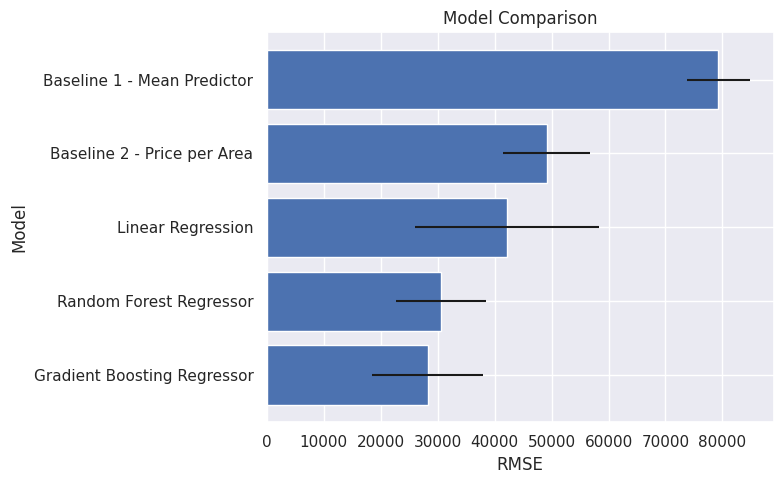

In [59]:
plt.figure(figsize=(8, 5))

plt.barh(
    results_df["Model"],
    results_df["RMSE Mean"],
    xerr=results_df["RMSE Std"]
)

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Model Comparison")

plt.tight_layout()
plt.show()

### Discussion

The comparison highlights how each modeling approach improves upon the previous ones:

- The **Mean Predictor** provides a naive benchmark and represents the minimum performance level.
- The **Price-per-Area model** introduces a simple domain-driven assumption and typically improves upon the constant baseline.
- **Linear Regression** leverages all engineered features under a linear assumption, capturing broader relationships in the data.
- **Random Forest** improves performance further by modeling nonlinearities and feature interactions.
- **Gradient Boosting** often achieves the best performance by sequentially correcting prediction errors and optimizing predictive accuracy.

The results should be interpreted not only in terms of absolute RMSE values, but also in terms of how effectively each model leverages the engineered feature set.

### Model Selection

Based on cross-validation performance, the model with the lowest average RMSE is selected as the final model. This model will be retrained on the full training dataset and used to generate predictions for the Kaggle test set.

## Train Final Model

After comparing all models using cross-validation, we select the best-performing approach based on the lowest average RMSE. This model is then retrained using the full training dataset in order to maximize the amount of information available during learning.

Unlike cross-validation, where the model is trained on subsets of the data, the final model is fitted on all available labeled observations. This ensures that no information from the training set is wasted before generating predictions for the test set.

The trained model is then used to produce predictions for the Kaggle test dataset, which will be submitted for evaluation on the competition leaderboard.

In [60]:
# Select best model
best_model_name = results_df.sort_values("RMSE Mean").iloc[0]["Model"]

print("Best model:", best_model_name)

# Map model names to objects
model_map = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

best_model = model_map[best_model_name]

# Train on full training set
best_model.fit(X_train, y_train)

# Predict on test set
test_preds = best_model.predict(X_test)

Best model: Gradient Boosting Regressor


## Model Diagnostics

After selecting and training the final model, it is useful to inspect its predictions visually. While cross-validation metrics provide a quantitative measure of performance, diagnostic plots can reveal systematic patterns that may not be immediately apparent from summary statistics alone.

In particular, we compare predicted and actual sale prices to assess how closely the model captures the observed values. We also examine residuals to identify potential biases, such as systematic underestimation or overestimation in specific price ranges.

These diagnostics provide additional confidence that the model is behaving as expected before generating predictions for the Kaggle test set.

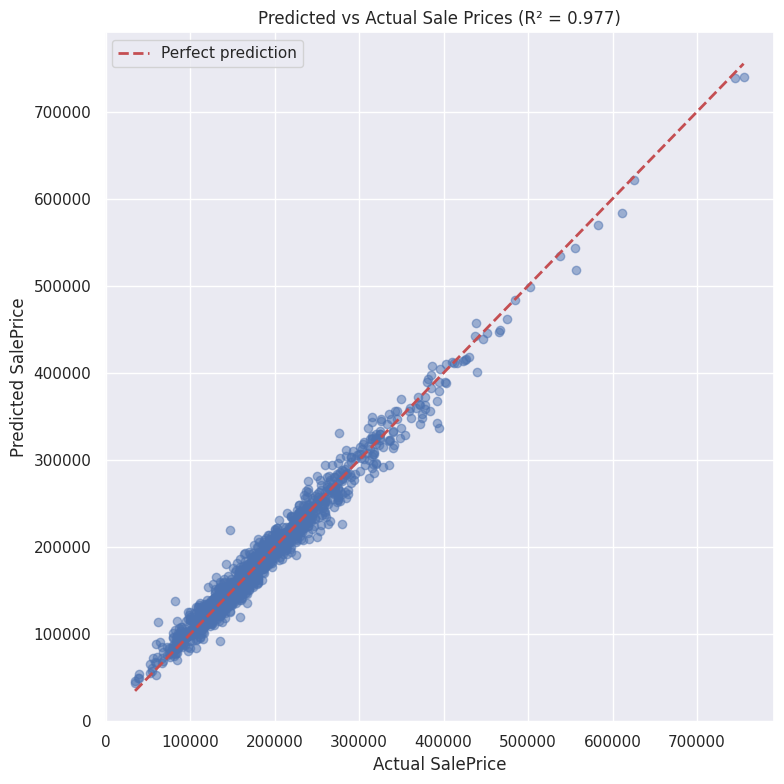

In [61]:
# Fit final model on all training data
best_model.fit(X_train, y_train)

# Predictions on training data
train_preds = best_model.predict(X_train)

# Predicted vs Actual
plt.figure(figsize=(8, 8))

plt.scatter(
    y_train,
    train_preds,
    alpha=0.5
)

# Perfect prediction line
min_val = min(y_train.min(), train_preds.min())
max_val = max(y_train.max(), train_preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual Sale Prices")
plt.legend()

plt.tight_layout()

r2 = r2_score(y_train, train_preds)
plt.title(f"Predicted vs Actual Sale Prices (R² = {r2:.3f})")

plt.show()

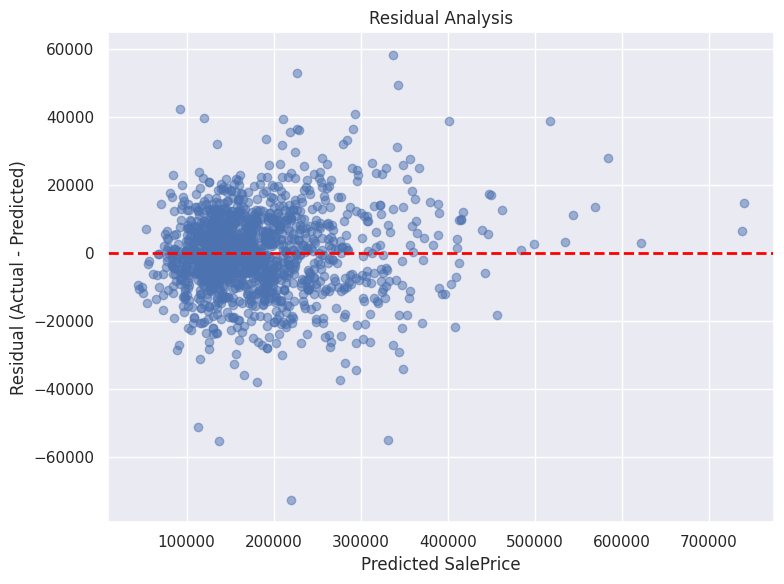

In [62]:
# Residuals
residuals = y_train - train_preds

plt.figure(figsize=(8, 6))

plt.scatter(
    train_preds,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

## Feature Importance

To better understand the behavior of the selected Gradient Boosting model, we examine feature importance scores.

Feature importance quantifies how much each feature contributes to reducing prediction error throughout the ensemble of decision trees.

Although these scores should not be interpreted as causal relationships, they provide useful insight into which property characteristics were most influential in determining house prices.

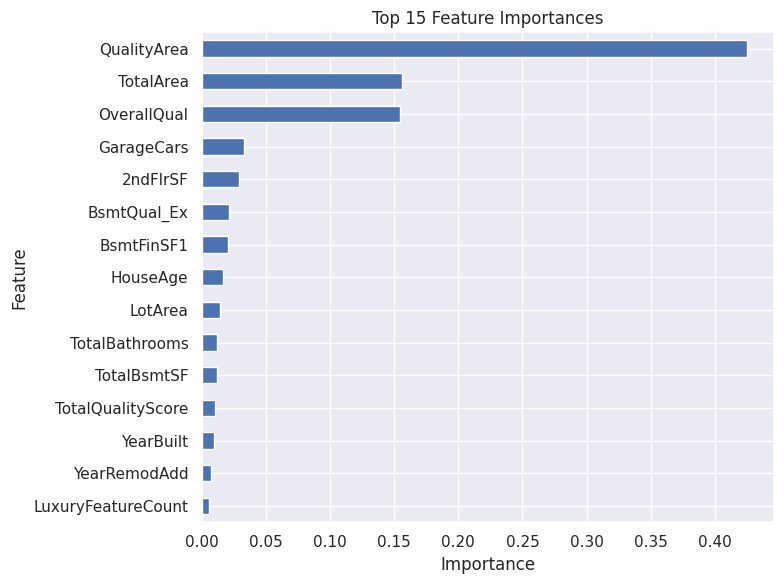

In [63]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

plt.figure(figsize=(8, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

Several engineered features appear among the most important predictors, suggesting that the feature engineering process successfully captured information beyond the original dataset variables.

In particular, features related to overall quality, living area, and quality-adjusted size contribute substantially to the model's predictive power. This aligns with the patterns observed during the exploratory analysis, where house size and construction quality showed strong relationships with sale price.

## Create Submission File

With the final model trained on the full training dataset, we now generate predictions for the Kaggle test set. These predictions represent our model’s estimates of the sale price for each unseen property.

The submission file must follow the format required by the competition, containing the `Id` column and the corresponding predicted `SalePrice`.

In [64]:
import pandas as pd

submission = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": test_preds
})

submission.to_csv("data/submission.csv", index=False)

submission

,Id,SalePrice
1460,1461,123331.355526
1461,1462,162667.570223
1462,1463,182114.213300
1463,1464,191971.372321
1464,1465,184946.133686
...,...,...
2914,2915,89236.680527
2915,2916,79689.737652
2916,2917,149279.200042
2917,2918,121035.983276


## Final Summary

In this notebook, we completed the end-to-end modeling pipeline for the House Prices prediction problem.

We began by establishing simple baseline models, including a constant mean predictor and a price-per-area heuristic. These provided reference points to evaluate the benefit of more complex approaches.

We then trained and evaluated several machine learning models, including Linear Regression, Random Forest, and Gradient Boosting, using a consistent cross-validation strategy based on RMSE. This allowed for a fair comparison across all methods.

The results showed that increasing model complexity generally improved predictive performance, with ensemble methods outperforming simpler linear approaches.

Finally, we selected the best-performing model, retrained it on the full training dataset, and generated predictions for the Kaggle test set. These predictions were saved in the required submission format.

This completes the modeling pipeline. Future improvements could include hyperparameter tuning, feature selection, stacking models, or more advanced gradient boosting frameworks such as XGBoost, LightGBM, or CatBoost.